# 📈 Multiple Linear Regression — Economic Index Price Prediction

**Author:** Srikant Sinha
**Date:** March 2026  
**Dataset:** Economic Index Dataset 
**Tools:** Python · Scikit-learn · Statsmodels · Seaborn · Matplotlib

---

## 🧭 Project Overview

In this project, we build a **Multiple Linear Regression** model to predict the **Stock Index Price** using two macroeconomic indicators:

- **Interest Rate** — the central bank lending rate
- **Unemployment Rate** — the percentage of unemployed population

This is a follow-up to my Simple Linear Regression project, extending the concept to **multiple input features**.

---

## 🎯 Objectives

1. Explore and understand the dataset through EDA
2. Visualize relationships between features and target variable
3. Build and train a Multiple Linear Regression model
4. Evaluate performance using MAE, MSE, RMSE, and R²
5. Validate the model using K-Fold Cross Validation
6. Diagnose model quality through residual analysis
7. Interpret coefficients using the Statsmodels OLS summary

---

## 📋 Table of Contents

1. [Import Libraries](#1)
2. [Load & Explore Data](#2)
3. [Data Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Feature & Target Separation](#5)
6. [Train-Test Split](#6)
7. [Feature Scaling](#7)
8. [Model Building & Training](#8)
9. [Cross-Validation](#9)
10. [Predictions & Evaluation Metrics](#10)
11. [Residual Analysis](#11)
12. [OLS Statistical Summary](#12)
13. [Predicting on New Data](#13)
14. [Summary & Conclusions](#14)

---
## 1. Import Libraries <a id='1'></a>

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Import all required libraries
# ─────────────────────────────────────────────────────────────────────────────

# NumPy: numerical operations (array math, square roots, means)
import numpy as np

# Pandas: data loading, manipulation, and exploration
import pandas as pd

# Matplotlib: base plotting library
import matplotlib.pyplot as plt

# Seaborn: statistical data visualizations (pairplots, regplots, etc.)
import seaborn as sns

# Scikit-learn modules:
from sklearn.model_selection import train_test_split, cross_val_score  # splitting & cross-validation
from sklearn.preprocessing import StandardScaler                        # feature standardization
from sklearn.linear_model import LinearRegression                       # the core ML model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # evaluation metrics

# Statsmodels: classical statistical modeling (OLS summary with p-values, confidence intervals)
import statsmodels.api as sm

# Display plots inline inside the notebook
%matplotlib inline

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 2. Load & Explore the Dataset <a id='2'></a>

The dataset contains **24 monthly records** from January 2016 to December 2017 with the following columns:

| Column | Description |
|--------|-------------|
| `year` | Year of observation |
| `month` | Month of observation |
| `interest_rate` | Central bank interest rate (%) |
| `unemployment_rate` | Unemployment rate (%) |
| `index_price` | Stock market index price (target variable) |

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2A: Load the dataset from CSV
# ─────────────────────────────────────────────────────────────────────────────

# Read the CSV file into a pandas DataFrame
df_index = pd.read_csv('economic_index.csv')

# Display the first 5 rows to get a quick look at the data structure
print("📊 First 5 rows of the dataset:")
df_index.head()

📊 First 5 rows of the dataset:


,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2B: Basic dataset information
# ─────────────────────────────────────────────────────────────────────────────

print(f"Shape of dataset: {df_index.shape}")   # rows × columns
print(f"\nColumn names: {list(df_index.columns)}")
print(f"\nData types:")
print(df_index.dtypes)
print(f"\nMissing values per column:")
print(df_index.isnull().sum())   # check for any null values — important before modeling

Shape of dataset: (24, 6)

Column names: ['Unnamed: 0', 'year', 'month', 'interest_rate', 'unemployment_rate', 'index_price']

Data types:
Unnamed: 0             int64
year                   int64
month                  int64
interest_rate        float64
unemployment_rate    float64
index_price            int64
dtype: object

Missing values per column:
Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2C: Descriptive statistics
# ─────────────────────────────────────────────────────────────────────────────

# Gives us count, mean, std, min, max, and quartile info for every numeric column
# This helps spot outliers and understand the scale of each feature
print("📈 Descriptive Statistics:")
df_index.describe()

📈 Descriptive Statistics:


,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
count,24.000000,24.000000,24.000000,24.000000,24.00000,24.000000
mean,11.500000,2016.500000,6.500000,2.072917,5.77500,1070.083333
std,7.071068,0.510754,3.526299,0.349527,0.33002,210.735341
min,0.000000,2016.000000,1.000000,1.750000,5.30000,704.000000
25%,5.750000,2016.000000,3.750000,1.750000,5.50000,928.250000
50%,11.500000,2016.500000,6.500000,2.000000,5.85000,1061.000000
75%,17.250000,2017.000000,9.250000,2.500000,6.10000,1239.000000
max,23.000000,2017.000000,12.000000,2.750000,6.20000,1464.000000


---
## 3. Data Preprocessing <a id='3'></a>

We drop columns that are not useful for prediction: `Unnamed: 0`, `year`, and `month`. These are either index artifacts or time identifiers — not genuine economic predictors for our simple model.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Drop irrelevant columns
# ─────────────────────────────────────────────────────────────────────────────

# 'Unnamed: 0' is just a row index artifact from the CSV
# 'year' and 'month' are time labels — not meaningful numeric predictors here
# inplace=True modifies the DataFrame directly without creating a copy
df_index.drop(columns=['Unnamed: 0', 'year', 'month'], axis=1, inplace=True)

print("✅ Cleaned DataFrame — remaining columns:")
df_index.head()

✅ Cleaned DataFrame — remaining columns:


,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


---
## 4. Exploratory Data Analysis (EDA) <a id='4'></a>

EDA helps us understand the relationships between variables BEFORE building the model. We will:
- Use a **pairplot** to see all pairwise relationships at once
- Check the **correlation matrix** for linear relationships
- Use **regression plots** to visualize individual feature vs target relationships

🔍 Pairplot — visualizing all relationships:


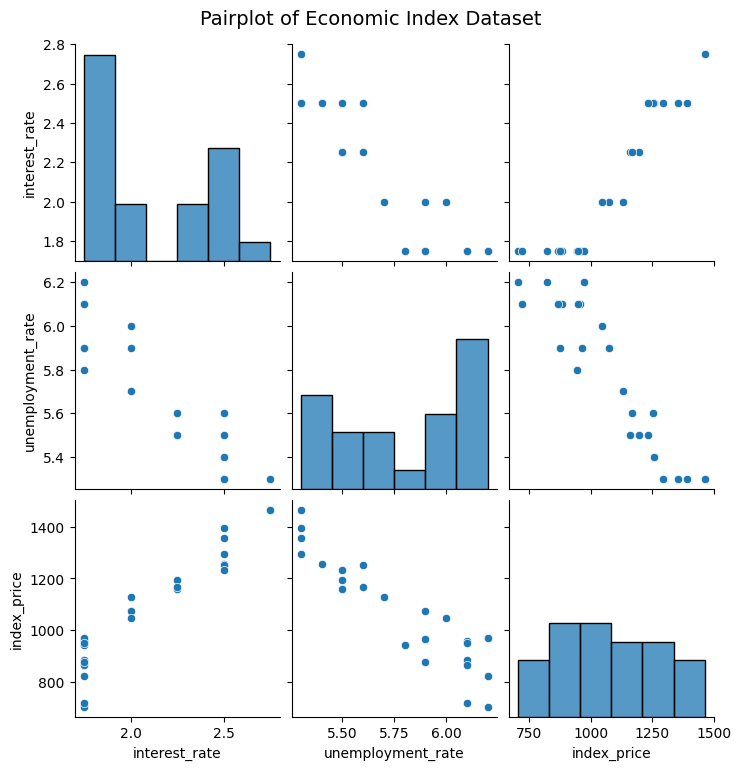

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4A: Pairplot — all pairwise scatter plots at once
# ─────────────────────────────────────────────────────────────────────────────

# A pairplot creates a grid of scatter plots for every combination of features
# Diagonal shows distribution of each variable (kde or histogram)
# This is the fastest way to spot linear or non-linear patterns between variables
print("🔍 Pairplot — visualizing all relationships:")
sns.pairplot(df_index)
plt.suptitle('Pairplot of Economic Index Dataset', y=1.02, fontsize=14)
plt.show()

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4B: Correlation Matrix
# ─────────────────────────────────────────────────────────────────────────────

# Correlation values range from -1 to +1:
#   +1 = perfect positive linear relationship
#   -1 = perfect negative linear relationship
#    0 = no linear relationship
# We want our features to correlate STRONGLY with the target (index_price)
# but NOT too strongly with each other (to avoid multicollinearity)
print("🔗 Correlation Matrix:")
corr = df_index.corr()
print(corr)

# 📌 Observation:
# interest_rate    ↔ index_price:    +0.94  ← strong positive correlation
# unemployment_rate ↔ index_price:  -0.92  ← strong negative correlation
# interest_rate    ↔ unemployment_rate: -0.93  ← high multicollinearity (to keep in mind!)

🔗 Correlation Matrix:
                   interest_rate  unemployment_rate  index_price
interest_rate           1.000000          -0.925814     0.935793
unemployment_rate      -0.925814           1.000000    -0.922338
index_price             0.935793          -0.922338     1.000000


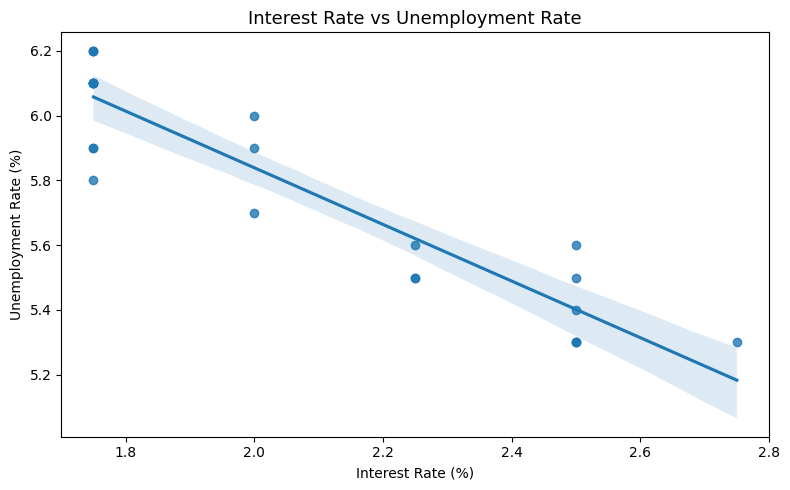

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4C: Regression plot — Interest Rate vs Unemployment Rate
# ─────────────────────────────────────────────────────────────────────────────

# regplot shows scatter points + a regression line with confidence band
# This confirms the negative linear relationship between the two features
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['unemployment_rate']
)
plt.title('Interest Rate vs Unemployment Rate', fontsize=13)
plt.xlabel('Interest Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

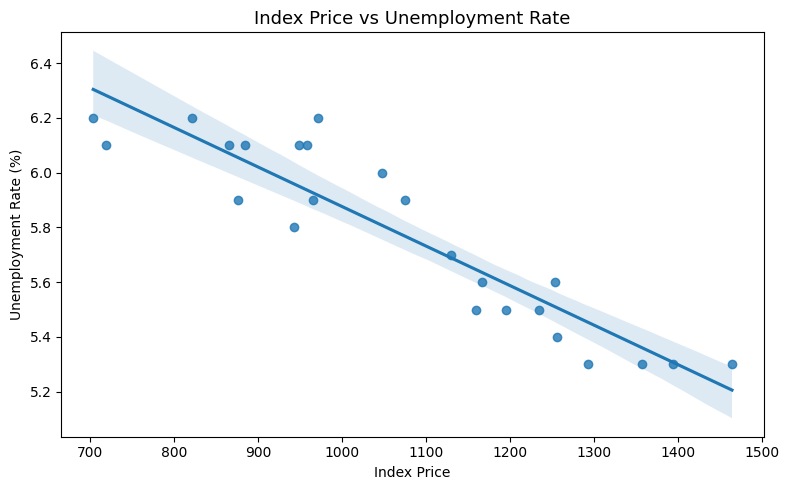

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4D: Regression plot — Index Price vs Unemployment Rate
# ─────────────────────────────────────────────────────────────────────────────

# As unemployment rate increases, index price decreases — a clear negative trend
# This makes economic sense: higher unemployment → weaker economy → lower stock prices
plt.figure(figsize=(8, 5))
sns.regplot(
    x=df_index['index_price'],
    y=df_index['unemployment_rate']
)
plt.title('Index Price vs Unemployment Rate', fontsize=13)
plt.xlabel('Index Price')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

---
## 5. Feature & Target Separation <a id='5'></a>

In supervised learning we split data into:
- **X (features)** — the inputs the model learns from
- **y (target)** — what the model is trying to predict

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Separate features (X) and target (y)
# ─────────────────────────────────────────────────────────────────────────────

# X = all columns EXCEPT the last one (index_price)
# iloc[:, :-1] means: all rows, all columns except the last
X = df_index.iloc[:, :-1]   # features: interest_rate, unemployment_rate

# y = only the last column (index_price) — this is what we want to predict
y = df_index.iloc[:, -1]    # target: index_price

print("Feature matrix X (first 5 rows):")
print(X.head())
print(f"\nTarget vector y (first 5 values):")
print(y.head())
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Feature matrix X (first 5 rows):
   interest_rate  unemployment_rate
0           2.75                5.3
1           2.50                5.3
2           2.50                5.3
3           2.50                5.3
4           2.50                5.4

Target vector y (first 5 values):
0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

X shape: (24, 2)
y shape: (24,)


---
## 6. Train-Test Split <a id='6'></a>

We split data into **75% training** and **25% testing**.

- **Training set** — the model learns from this
- **Test set** — used to evaluate how well the model generalizes to unseen data

`random_state=42` ensures reproducible results every time you run the notebook.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Train-Test Split
# ─────────────────────────────────────────────────────────────────────────────

# test_size=0.25 → 25% of data goes to testing, 75% to training
# random_state=42 → fixes the random seed so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training samples:  {X_train.shape[0]}")
print(f"Test samples:      {X_test.shape[0]}")
print(f"Total samples:     {X.shape[0]}")

Training samples:  18
Test samples:      6
Total samples:     24


---
## 7. Feature Scaling (Standardization) <a id='7'></a>

**StandardScaler** transforms each feature so that it has:
- **Mean = 0**
- **Standard Deviation = 1**

**Why is this important?**  
Interest rate (2–3%) and index price (700–1464) are on very different scales. Without scaling, the model might give disproportionate weight to the larger-valued feature.

> ⚠️ **Key rule:** Always `fit` the scaler on training data only, then `transform` both train and test. This prevents **data leakage** — the scaler must not learn anything from the test set.

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: Feature Scaling using StandardScaler
# ─────────────────────────────────────────────────────────────────────────────

# Initialize the scaler
scaler = StandardScaler()

# fit_transform on training data: learns mean & std from X_train, then scales it
X_train = scaler.fit_transform(X_train)

# transform on test data: uses the SAME mean & std learned from training
# (do NOT fit again — that would leak test information)
X_test = scaler.transform(X_test)

print("✅ Feature scaling applied.")
print(f"Scaled X_train mean (approx 0): {X_train.mean(axis=0).round(4)}")
print(f"Scaled X_train std  (approx 1): {X_train.std(axis=0).round(4)}")

✅ Feature scaling applied.
Scaled X_train mean (approx 0): [0. 0.]
Scaled X_train std  (approx 1): [1. 1.]


---
## 8. Model Building & Training <a id='8'></a>

We use **scikit-learn's LinearRegression**, which fits the equation:

$$\hat{y} = \beta_0 + \beta_1 \cdot \text{interest\_rate} + \beta_2 \cdot \text{unemployment\_rate}$$

The model finds the coefficients (β values) that **minimize the sum of squared errors** between predicted and actual values.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: Build and train the Linear Regression model
# ─────────────────────────────────────────────────────────────────────────────

# Initialize the regression model
regression = LinearRegression()

# Train the model: find the best-fit coefficients using Ordinary Least Squares (OLS)
# X_train → scaled features, y_train → actual index prices
regression.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"\nIntercept (β₀):          {regression.intercept_:.4f}")
print(f"Coefficient for interest_rate (β₁):      {regression.coef_[0]:.4f}")
print(f"Coefficient for unemployment_rate (β₂):  {regression.coef_[1]:.4f}")

# Interpretation:
# β₁ > 0: as interest_rate increases (after scaling), index_price increases
# β₂ < 0: as unemployment_rate increases (after scaling), index_price decreases

✅ Model trained successfully!

Intercept (β₀):          1053.4444
Coefficient for interest_rate (β₁):      88.2728
Coefficient for unemployment_rate (β₂):  -116.2572


---
## 9. Cross-Validation <a id='9'></a>

**K-Fold Cross-Validation** gives a more reliable estimate of model performance than a single train/test split.

With `cv=3`, the training data is split into 3 equal folds. The model is trained 3 times — each time using a different fold as the validation set. The scores are averaged for a robust estimate.

> Note: `neg_mean_squared_error` returns negative values because sklearn follows a convention where **higher = better**. We negate it to get the actual MSE.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: K-Fold Cross Validation (cv=3)
# ─────────────────────────────────────────────────────────────────────────────

# Perform 3-fold cross-validation on the training data
# scoring='neg_mean_squared_error': returns negative MSE (sklearn convention: higher is better)
validation_scores = cross_val_score(
    regression,
    X_train,
    y_train,
    scoring='neg_mean_squared_error',
    cv=3
)

# Each fold gives a score — we average them
mean_cv_mse   = abs(np.mean(validation_scores))   # convert to positive MSE
mean_cv_rmse  = np.sqrt(mean_cv_mse)              # RMSE is in the same units as the target

print(f"Individual fold scores (neg MSE): {validation_scores.round(2)}")
print(f"\nMean Cross-Validation MSE:  {mean_cv_mse:.2f}")
print(f"Mean Cross-Validation RMSE: {mean_cv_rmse:.2f} index points")
print("\n📌 On average, the model is off by ~{:.0f} index points across all folds.".format(mean_cv_rmse))

Individual fold scores (neg MSE): [-4921.61 -7686.87 -5136.  ]

Mean Cross-Validation MSE:  5914.83
Mean Cross-Validation RMSE: 76.91 index points

📌 On average, the model is off by ~77 index points across all folds.


---
## 10. Predictions & Evaluation Metrics <a id='10'></a>

We evaluate model performance on the **unseen test set** using:

| Metric | What it measures |
|--------|------------------|
| **MAE** | Average absolute error — intuitive, same units as target |
| **MSE** | Average squared error — penalizes large errors heavily |
| **RMSE** | Square root of MSE — back in original units |
| **R²** | % of variance explained by the model (0–1, higher is better) |
| **Adjusted R²** | R² penalized for number of features (more honest for small datasets) |

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10A: Make predictions on the test set
# ─────────────────────────────────────────────────────────────────────────────

# Use the trained model to predict index prices for the test set
y_pred = regression.predict(X_test)

print("📊 Predicted vs Actual:")
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
comparison['Error'] = (comparison['Actual'] - comparison['Predicted']).round(2)
print(comparison.to_string(index=False))

📊 Predicted vs Actual:
 Actual  Predicted  Error
   1159    1204.23 -45.23
    971     821.65 149.35
   1464    1406.51  57.49
    884     857.71  26.29
   1075     994.91  80.09
   1167    1168.17  -1.17


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10B: Calculate all evaluation metrics
# ─────────────────────────────────────────────────────────────────────────────

# MAE: average of |actual - predicted| — each error weighted equally
mae = mean_absolute_error(y_test, y_pred)

# MSE: average of (actual - predicted)² — larger errors are penalized more
mse = mean_squared_error(y_test, y_pred)

# RMSE: √MSE — brings the error back to the same unit as index_price
rmse = np.sqrt(mse)

# R²: proportion of variance in y explained by the model
# R² = 1 means perfect prediction; R² = 0 means no better than predicting the mean
r2 = r2_score(y_test, y_pred)

# Adjusted R²: penalizes R² for number of features
# Formula: 1 - (1 - R²) * (n-1)/(n-p-1)   where n=samples, p=features
n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("─" * 40)
print(f"  MAE          : {mae:.4f}")
print(f"  MSE          : {mse:.4f}")
print(f"  RMSE         : {rmse:.4f}")
print(f"  R²           : {r2:.4f}")
print(f"  Adjusted R²  : {adjusted_r2:.4f}")
print("─" * 40)
print(f"\n📌 On average, predictions are off by ~{mae:.0f} index points (MAE).")
print(f"📌 The model explains {r2*100:.1f}% of the variance in index price (R²).")

────────────────────────────────────────
  MAE          : 59.9358
  MSE          : 5793.7629
  RMSE         : 76.1168
  R²           : 0.8279
  Adjusted R²  : 0.7132
────────────────────────────────────────

📌 On average, predictions are off by ~60 index points (MAE).
📌 The model explains 82.8% of the variance in index price (R²).


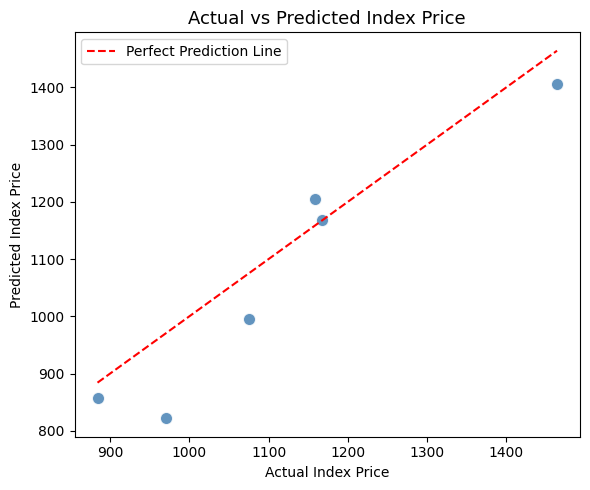

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10C: Scatter plot — Actual vs Predicted
# ─────────────────────────────────────────────────────────────────────────────

# If the model is perfect, all points would lie on a diagonal line
# Points far from the diagonal indicate large prediction errors
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color='steelblue', edgecolors='white', s=80, alpha=0.85)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=1.5, label='Perfect Prediction Line')
plt.xlabel('Actual Index Price')
plt.ylabel('Predicted Index Price')
plt.title('Actual vs Predicted Index Price', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

---
## 11. Residual Analysis <a id='11'></a>

**Residuals** = Actual − Predicted

A well-behaved model should produce residuals that are:
- **Randomly scattered** around zero (no pattern)
- **Approximately normally distributed**
- **Not fanning out** (no heteroscedasticity)

Patterns in residuals reveal what the model is missing.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11A: Calculate residuals
# ─────────────────────────────────────────────────────────────────────────────

# Residual = actual value - predicted value
# Positive residual → model UNDER-predicted (actual was higher)
# Negative residual → model OVER-predicted (actual was lower)
residuals = y_test - y_pred

print("📋 Residuals (Actual - Predicted):")
print(residuals.round(2))
print(f"\nMean of residuals (should be ~0): {residuals.mean():.4f}")
print(f"Std of residuals:                  {residuals.std():.4f}")

📋 Residuals (Actual - Predicted):
8     -45.23
16    149.35
0      57.49
18     26.29
11     80.09
9      -1.17
Name: index_price, dtype: float64

Mean of residuals (should be ~0): 44.4701
Std of residuals:                  67.6713


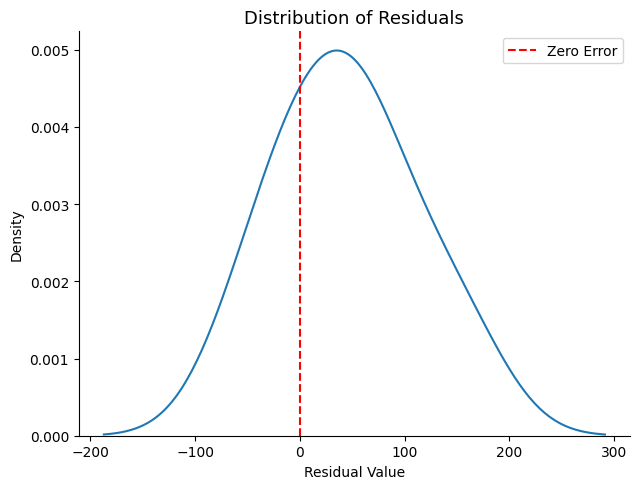

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11B: Residuals Distribution Plot (KDE)
# ─────────────────────────────────────────────────────────────────────────────

# KDE (Kernel Density Estimate) shows the distribution of residuals
# Ideally should be bell-shaped and centered at 0 → normally distributed errors
sns.displot(residuals, kind='kde', height=5, aspect=1.3)
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Residual Value')
plt.title('Distribution of Residuals', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

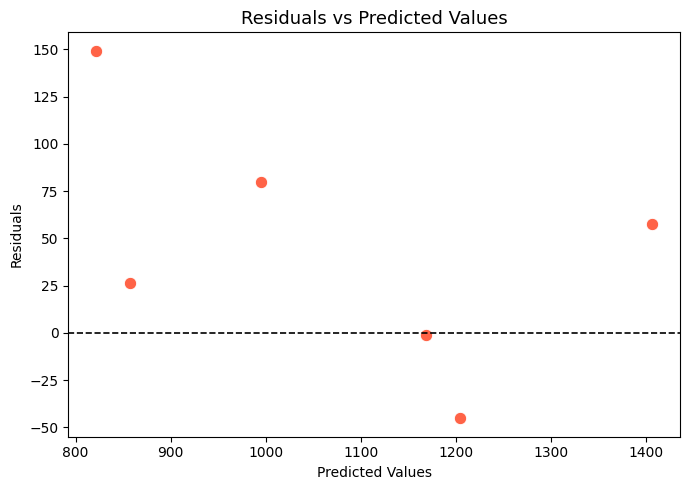


📌 Observation: With only 6 test points, it's hard to draw strong conclusions.
   One outlier (~+149) is pulling RMSE higher than MAE — a sign of an influential point.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11C: Residuals vs Predicted Values Plot
# ─────────────────────────────────────────────────────────────────────────────

# This plot is used to check for HETEROSCEDASTICITY
# If residuals fan out as predictions increase → the model has unequal variance (problematic)
# Ideally: residuals should be scattered randomly around the horizontal zero line
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=residuals, color='tomato', s=80)
plt.axhline(0, color='black', linestyle='--', lw=1.2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values', fontsize=13)
plt.tight_layout()
plt.show()

print("\n📌 Observation: With only 6 test points, it's hard to draw strong conclusions.")
print("   One outlier (~+149) is pulling RMSE higher than MAE — a sign of an influential point.")

---
## 12. OLS Statistical Summary (Statsmodels) <a id='12'></a>

Statsmodels provides a detailed **statistical summary** that sklearn does not. This includes:
- **p-values**: Is each coefficient statistically significant?
- **Confidence intervals**: Range of plausible coefficient values
- **F-statistic**: Is the overall model significant?
- **Durbin-Watson**: Checks for autocorrelation in residuals

> ⚠️ **Important:** We must add a constant (intercept) manually when using Statsmodels OLS.

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: OLS Regression using Statsmodels
# ─────────────────────────────────────────────────────────────────────────────

# Statsmodels does NOT add an intercept automatically — we must add it manually
# sm.add_constant() adds a column of 1s for the bias/intercept term
X_train_ols = sm.add_constant(X_train)

# Fit the OLS (Ordinary Least Squares) model
ols_model = sm.OLS(y_train, X_train_ols).fit()

# Display the full statistical summary
# Key things to look at:
#   R-squared / Adj. R-squared: model fit quality
#   P>|t| values: <0.05 means statistically significant
#   Coef: actual coefficient values
#   Durbin-Watson: ~2 means no autocorrelation in residuals (good)
ols_model.summary()

c:\Users\linkh\OneDrive\Desktop\courses\python\ai ml course\Linear Regression\multiple linear regression\myenv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            index_price   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     69.88
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.50e-08
Time:                        20:47:03   Log-Likelihood:                -100.85
No. Observations:                  18   AIC:                             207.7
Df Residuals:                      15   BIC:                             210.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1053.4444     16.941     62.183      0.000    1017.336    1089.553
x1            88.2728     42.263      2.089      0.054      -1.810     178.355
x2          -116.2572     42.263     -2.751      0.015    -206.340     -26.175
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12B: Interpret OLS Coefficients
# ─────────────────────────────────────────────────────────────────────────────

print("📌 OLS Summary Interpretation:")
print("-" * 50)
print(f"R-squared (train):     {ols_model.rsquared:.3f}")
print(f"Adj. R-squared (train): {ols_model.rsquared_adj:.3f}")
print(f"F-statistic:           {ols_model.fvalue:.2f}  (p={ols_model.f_pvalue:.2e})")
print("-" * 50)
print("Coefficients:")
print(ols_model.params.round(4))
print("-" * 50)
print("P-values:")
print(ols_model.pvalues.round(4))
print("-" * 50)
print("\n💡 interest_rate:     p=0.054  (borderline — marginally significant at 10% level)")
print("💡 unemployment_rate: p=0.015  (statistically significant at 5% level ✅)")
print("💡 F-statistic p-value < 0.001 → the overall model is highly significant ✅")

📌 OLS Summary Interpretation:
--------------------------------------------------
R-squared (train):     0.903
Adj. R-squared (train): 0.890
F-statistic:           69.88  (p=2.50e-08)
--------------------------------------------------
Coefficients:
const    1053.4444
x1         88.2728
x2       -116.2572
dtype: float64
--------------------------------------------------
P-values:
const    0.0000
x1       0.0542
x2       0.0149
dtype: float64
--------------------------------------------------

💡 interest_rate:     p=0.054  (borderline — marginally significant at 10% level)
💡 unemployment_rate: p=0.015  (statistically significant at 5% level ✅)
💡 F-statistic p-value < 0.001 → the overall model is highly significant ✅


---
## 13. Predicting on New Data <a id='13'></a>

Let's predict the index price for a new observation:
- Interest Rate: **2.75%**
- Unemployment Rate: **5.3%**

> ⚠️ **Critical:** New data must be scaled using the **same scaler** fitted on training data before predicting!

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: Predict on new unseen data
# ─────────────────────────────────────────────────────────────────────────────

# New input: interest_rate=2.75, unemployment_rate=5.3
# (This matches row 0 of the original dataset where actual index_price = 1464)
new_data = np.array([[2.75, 5.3]])

# STEP 1: Scale the new data using the SAME scaler fitted on training data
# ⚠️ Common mistake: forgetting to scale, or refitting the scaler — both give wrong results
new_data_scaled = scaler.transform(new_data)

# STEP 2A: Predict using sklearn LinearRegression
sklearn_pred = regression.predict(new_data_scaled)
print(f"Sklearn prediction:      {sklearn_pred[0]:.2f}")

# STEP 2B: Predict using Statsmodels OLS (needs constant added)
new_data_ols = sm.add_constant(new_data_scaled, has_constant='add')
ols_pred = ols_model.predict(new_data_ols)
print(f"Statsmodels OLS pred:    {ols_pred[0]:.2f}")

print(f"\nActual index price (row 0): 1464")
print(f"Prediction error:          ~{1464 - sklearn_pred[0]:.1f} points ({abs(1464 - sklearn_pred[0])/1464*100:.1f}% off)")
print("\n📌 A ~4% error on this prediction is better than our average MAE (~60 points).")

Sklearn prediction:      1406.51
Statsmodels OLS pred:    1406.51

Actual index price (row 0): 1464
Prediction error:          ~57.5 points (3.9% off)

📌 A ~4% error on this prediction is better than our average MAE (~60 points).


c:\Users\linkh\OneDrive\Desktop\courses\python\ai ml course\Linear Regression\multiple linear regression\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


---
## 14. Summary & Conclusions <a id='14'></a>

### 📊 Model Performance Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| MAE | ~60 pts | Average prediction error |
| RMSE | ~76 pts | Penalized error (outlier-sensitive) |
| R² | 0.83 | Model explains 83% of variance |
| Adjusted R² | 0.71 | Penalized for features & small sample |
| CV RMSE | ~77 pts | Consistent across folds ✅ |

### 🔑 Key Findings

1. **Both macroeconomic features** are meaningful predictors of the stock index price.
2. **Unemployment rate** is the more statistically significant predictor (p=0.015).
3. **Interest rate** is borderline significant (p=0.054) — more data would help confirm it.
4. **Cross-validation RMSE (~77)** and **test RMSE (~76)** are very close → the model is **stable and not overfitting**.
5. **RMSE > MAE** indicates one outlier (residual ≈ +149) is inflating the error.

### ⚠️ Limitations

- Only **24 data points** — very small dataset for machine learning
- **High multicollinearity** between interest_rate and unemployment_rate (r = -0.93)
- **Only 2 features** — real stock market indices are driven by many more factors
- Adjusted R² drops sharply (0.83 → 0.71) due to small test set size

### 🚀 Next Steps

- Collect more data to improve reliability
- Add more features (inflation rate, GDP growth, etc.)
- Try Ridge/Lasso regression to handle multicollinearity
- Experiment with polynomial features for non-linear relationships

---
*This notebook was created as a learning project to demonstrate Multiple Linear Regression from data exploration through model evaluation.*